In [ ]:
import pandas as pd

df = pd.read_csv('/content/customer_support_tickets_processed_final.csv')

print("Shape:", df.shape)
print("\nColumns:\n")
for col in df.columns:
    print(col)

Shape: (200000, 39)

Columns:

ticket_id
customer_name
customer_email
product
category
issue_description
resolution_notes
priority
status
channel
region
customer_age
customer_gender
subscription_type
customer_tenure_months
previous_tickets
customer_satisfaction_score
first_response_time_hours
resolution_time_hours
ticket_created_date
ticket_resolved_date
escalated
sla_breached
operating_system
browser
payment_method
language
preferred_contact_time
issue_complexity_score
customer_segment
Resolution_Duration
Resolution_Duration_Hours
Priority_Score
type
Queue
Cluster_ID
Cluster_Name
Similarity_Score
Similarity_Level


Task 1: Analyze Average Resolution Times by Priority and Type

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

df = pd.read_csv('/content/customer_support_tickets_processed_final.csv')

df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,customer_segment,Resolution_Duration,Resolution_Duration_Hours,Priority_Score,type,Queue,Cluster_ID,Cluster_Name,Similarity_Score,Similarity_Level
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,Small Business,3,72,4,Incident,Account Management,3,Account & Transaction Issues,0.484846,Medium
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,Small Business,13,312,4,Problem,Infrastructure Team,4,Software Bugs & Updates,1.000000,High
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,Corporate,5,120,2,Problem,Infrastructure Team,0,Application Errors,1.000000,High
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,Corporate,14,336,2,Request,Account Management,1,Billing & Subscription Issues,0.744156,High
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,Corporate,8,192,3,Request,Product Team,2,Data Synchronization Issues,1.000000,High


In [ ]:
print(df[['resolution_time_hours']].describe())

       resolution_time_hours
count          200000.000000
mean              120.539718
std                68.969143
min                 1.000000
25%                60.810000
50%               120.450000
75%               180.260000
max               240.000000


In [ ]:
priority_resolution = (
    df.groupby('priority')['resolution_time_hours']
      .mean()
      .sort_values(ascending=False)
)

print(priority_resolution)

priority
Low       121.026363
Urgent    120.705745
High      120.280082
Medium    120.148632
Name: resolution_time_hours, dtype: float64


/tmp/ipykernel_852/217642318.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


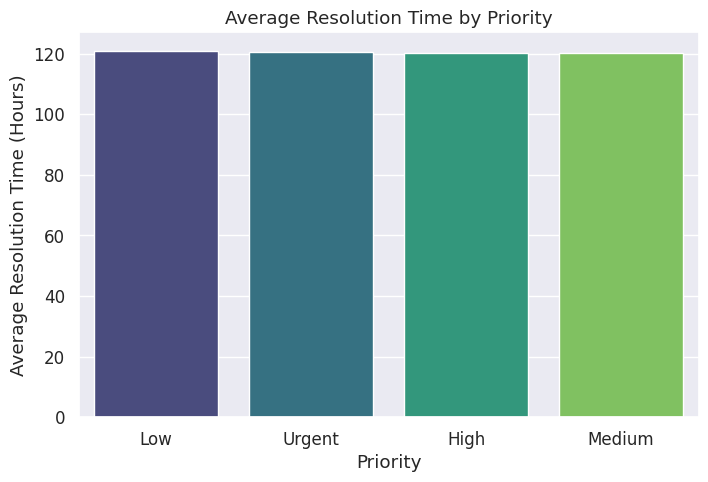

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=priority_resolution.index,
    y=priority_resolution.values,
    palette='viridis'
)

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (Hours)")

plt.show()

It compares the average resolution time across different priority levels to identify whether higher-priority tickets are resolved faster.

In [ ]:
type_resolution = (
    df.groupby('type')['resolution_time_hours']
      .mean()
      .sort_values(ascending=False)
)

print(type_resolution)

type
Incident    120.672458
Problem     120.607125
Request     120.318045
Name: resolution_time_hours, dtype: float64


/tmp/ipykernel_852/1673026866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


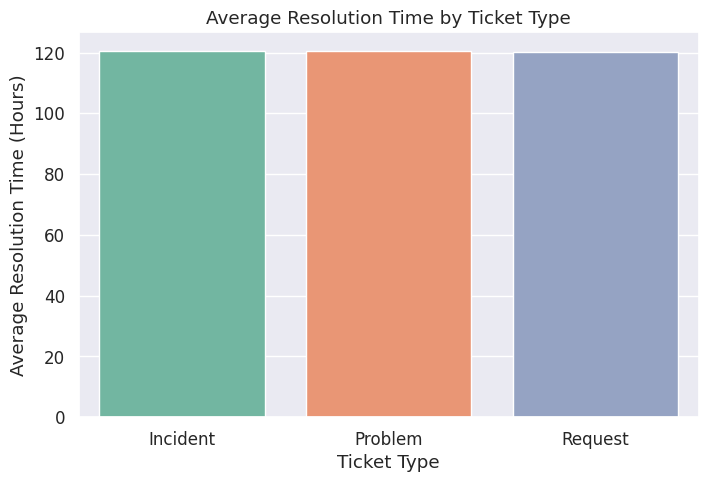

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=type_resolution.reset_index(),
    x='type',
    y='resolution_time_hours',
    palette='Set2'
)

plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Average Resolution Time (Hours)")

plt.show()

This compares resolution efficiency across different ticket types.

Task 2: Determine Which Regions or Teams Handle Tickets Fastest

In [ ]:
region_resolution = (
    df.groupby('region')['resolution_time_hours']
      .mean()
      .sort_values()
)

print(region_resolution)

region
Africa           120.206789
North America    120.208662
Australia        120.576541
South America    120.660512
Asia             120.666593
Europe           120.920070
Name: resolution_time_hours, dtype: float64


/tmp/ipykernel_852/104828681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


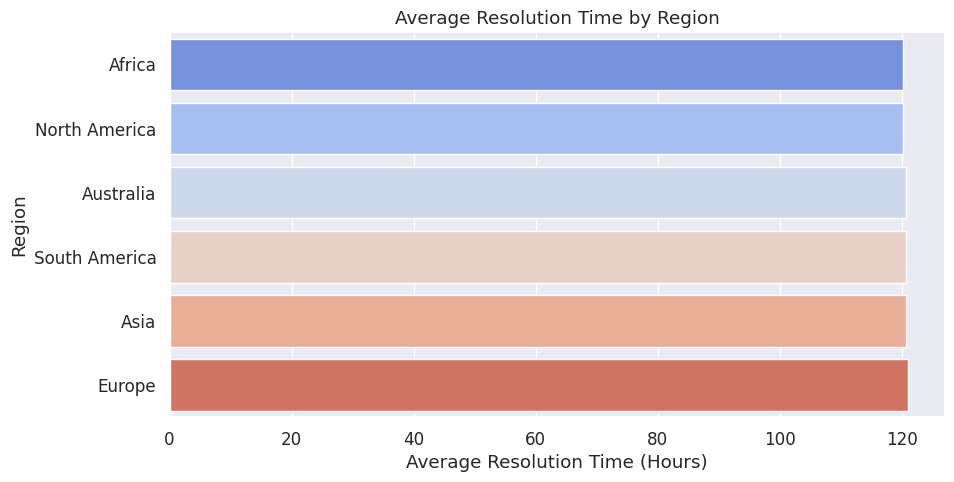

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=region_resolution.values,
    y=region_resolution.index,
    palette='coolwarm'
)

plt.title("Average Resolution Time by Region")
plt.xlabel("Average Resolution Time (Hours)")
plt.ylabel("Region")

plt.show()

To compare support performance across different geographic regions.

In [ ]:
team_resolution = (
    df.groupby('Queue')['resolution_time_hours']
      .mean()
      .sort_values()
)

print(team_resolution)

Queue
Development Team       120.318886
Security Team          120.362533
Billing Support        120.368262
Account Management     120.479402
Product Team           120.610610
Technical Support      120.661216
Infrastructure Team    120.873976
Name: resolution_time_hours, dtype: float64


/tmp/ipykernel_852/1548605214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


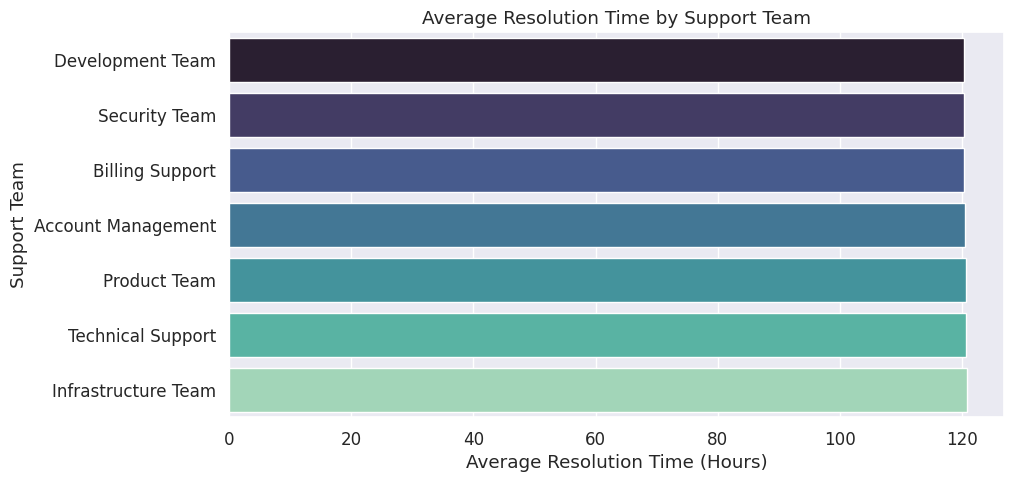

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=team_resolution.values,
    y=team_resolution.index,
    palette='mako'
)

plt.title("Average Resolution Time by Support Team")
plt.xlabel("Average Resolution Time (Hours)")
plt.ylabel("Support Team")

plt.show()

This identifies which support teams resolve tickets the fastest, helping evaluate team performance and workload efficiency.

Task 3: Identify High-Priority Unresolved Issues

In [ ]:
high_unresolved = df[
    (df['priority'].isin(['High', 'Urgent'])) &
    (~df['status'].isin(['Closed', 'Resolved']))
]

print(high_unresolved.shape)
high_unresolved.head()

(60289, 39)


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,customer_segment,Resolution_Duration,Resolution_Duration_Hours,Priority_Score,type,Queue,Cluster_ID,Cluster_Name,Similarity_Score,Similarity_Level
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,Small Business,3,72,4,Incident,Account Management,3,Account & Transaction Issues,0.484846,Medium
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,Corporate,8,192,3,Request,Product Team,2,Data Synchronization Issues,1.000000,High
13,14,Patricia Lopez,patricia.lopez799@hotmail.com,Payment Gateway,Account Suspension,The application crashes whenever I try to uplo...,The issue was escalated to engineering and res...,Urgent,Open,Chat,...,Individual,9,216,4,Incident,Account Management,0,Application Errors,1.000000,High
14,15,Michael Gonzalez,michael.gonzalez337@outlook.com,E-commerce Store,Feature Request,There seems to be a discrepancy in my billing ...,Data synchronization restored after backend se...,High,Open,Email,...,Individual,12,288,3,Request,Product Team,3,Account & Transaction Issues,0.429599,Medium
15,16,Susan Smith,susan.smith533@hotmail.com,Billing System,Refund Request,The payment was deducted from my bank account ...,Security settings updated and customer notifie...,High,Open,Phone,...,Small Business,5,120,3,Request,Billing Support,3,Account & Transaction Issues,0.484846,Medium


In [ ]:
high_unresolved['category'].value_counts()

,count
category,
Performance Issue,6161
Feature Request,6124
Security Concern,6096
Subscription Cancellation,6071
Bug Report,6020
Payment Problem,5993
Login Issue,5992
Account Suspension,5972
Refund Request,5933


In [ ]:
high_unresolved['Queue'].value_counts()

,count
Queue,
Infrastructure Team,12088
Account Management,12043
Billing Support,11926
Product Team,6124
Security Team,6096
Development Team,6020
Technical Support,5992


/tmp/ipykernel_852/1383147423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


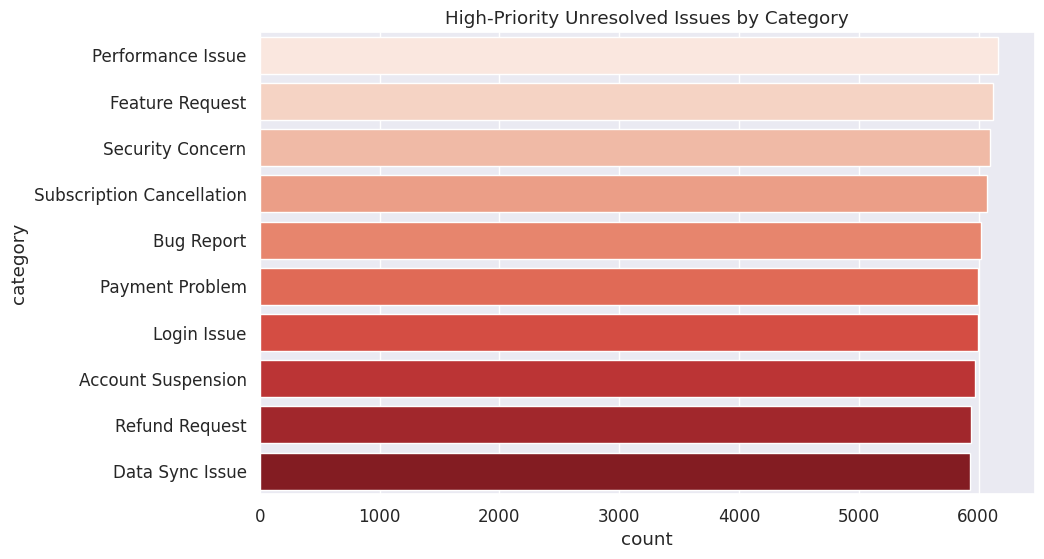

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=high_unresolved,
    y='category',
    order=high_unresolved['category'].value_counts().index,
    palette='Reds'
)

plt.title("High-Priority Unresolved Issues by Category")

plt.show()

This highlights which issue categories contribute most to unresolved high-priority tickets, helping identify critical operational bottlenecks.

In [ ]:
print(df['region'].unique())

['North America' 'South America' 'Europe' 'Asia' 'Africa' 'Australia']


In [ ]:
# Representative coordinates for each region

region_coordinates = {
    'North America': (54.5260, -105.2551),
    'South America': (-8.7832, -55.4915),
    'Europe': (54.5260, 15.2551),
    'Asia': (34.0479, 100.6197),
    'Africa': (1.6508, 17.6791),
    'Australia': (-25.2744, 133.7751),
    'Middle East': (29.2985, 42.5510)
}

# Create Latitude and Longitude columns

df['Latitude'] = df['region'].map(lambda x: region_coordinates[x][0])
df['Longitude'] = df['region'].map(lambda x: region_coordinates[x][1])

# Check
df[['region','Latitude','Longitude']].head()

,region,Latitude,Longitude
0,North America,54.5260,-105.2551
1,South America,-8.7832,-55.4915
2,Europe,54.5260,15.2551
3,Asia,34.0479,100.6197
4,Asia,34.0479,100.6197


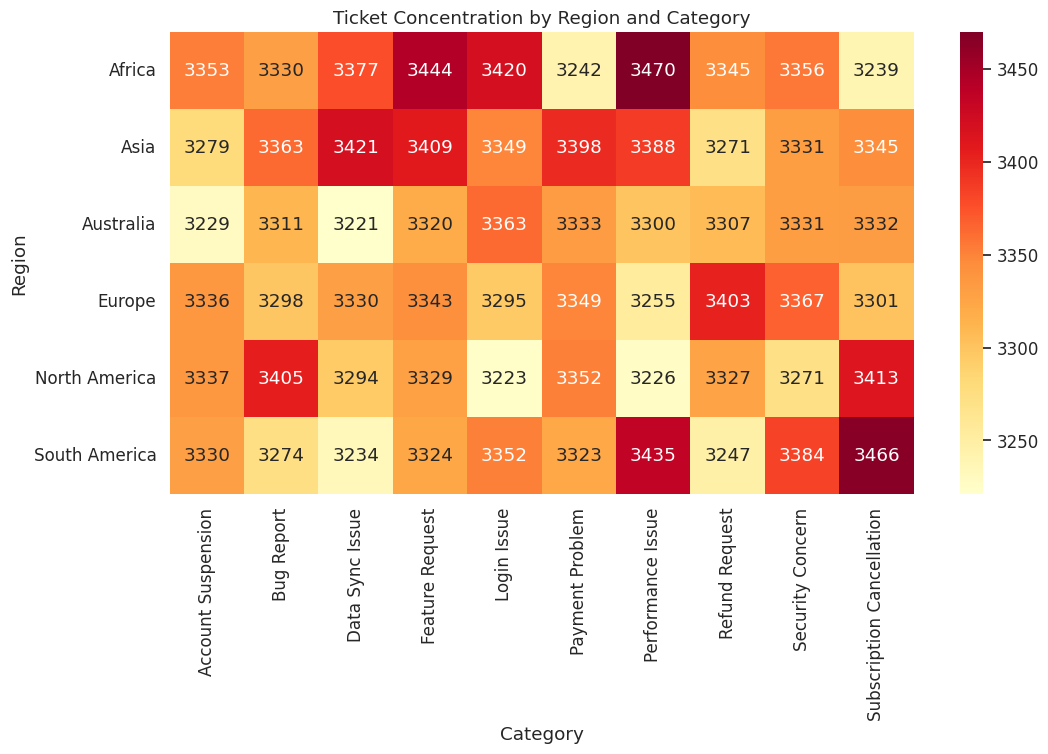

In [ ]:
region_category = pd.crosstab(df['region'], df['category'])

plt.figure(figsize=(12,6))

sns.heatmap(
    region_category,
    cmap='YlOrRd',
    annot=True,
    fmt='d'
)

plt.title("Ticket Concentration by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")

plt.show()

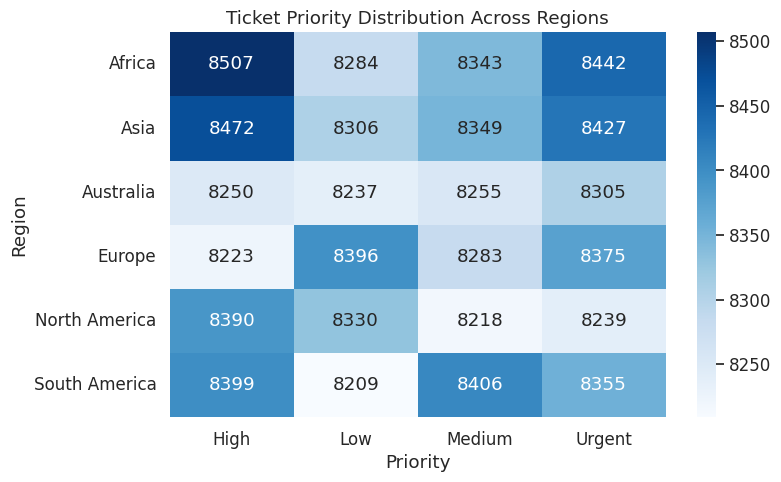

In [ ]:
region_priority = pd.crosstab(df['region'], df['priority'])

plt.figure(figsize=(8,5))

sns.heatmap(
    region_priority,
    cmap='Blues',
    annot=True,
    fmt='d'
)

plt.title("Ticket Priority Distribution Across Regions")
plt.xlabel("Priority")
plt.ylabel("Region")

plt.show()

In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px

geo_data = (
    df.groupby(['region','Latitude','Longitude'])
      .size()
      .reset_index(name='Ticket_Count')
)

fig = px.scatter_geo(
    geo_data,
    lat='Latitude',
    lon='Longitude',
    size='Ticket_Count',
    color='Ticket_Count',
    hover_name='region',
    projection='natural earth',
    title='Geographic Distribution of Support Tickets'
)

fig.show()

In [ ]:
print(df['sla_breached'].unique())

['Yes' 'No']


In [ ]:
df['SLA_Breach_Flag'] = df['sla_breached'].map({
    'Yes': 1,
    'No': 0
})

In [ ]:
print(df[['sla_breached', 'SLA_Breach_Flag']].head())

  sla_breached  SLA_Breach_Flag
0          Yes                1
1          Yes                1
2          Yes                1
3           No                0
4           No                0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['Resolution_Norm'] = scaler.fit_transform(df[['resolution_time_hours']])

df['Satisfaction_Norm'] = scaler.fit_transform(df[['customer_satisfaction_score']])

df['Similarity_Norm'] = scaler.fit_transform(df[['Similarity_Score']])

In [ ]:
df['Performance_Score'] = (
    0.4 * df['Satisfaction_Norm']
    + 0.3 * df['Similarity_Norm']
    - 0.2 * df['Resolution_Norm']
    - 0.1 * df['SLA_Breach_Flag'].astype(int)
)

In [ ]:
cluster_perf = (
    df.groupby('Cluster_Name')
      .agg(
          Cluster_Size=('Cluster_ID','count'),
          Avg_Performance=('Performance_Score','mean')
      )
      .reset_index()
)

cluster_perf

,Cluster_Name,Cluster_Size,Avg_Performance
0,Account & Transaction Issues,100378,0.064410
1,Application Errors,19883,0.350179
2,Billing & Subscription Issues,39890,0.219949
3,Data Synchronization Issues,19942,0.349748
4,Software Bugs & Updates,19907,0.349062


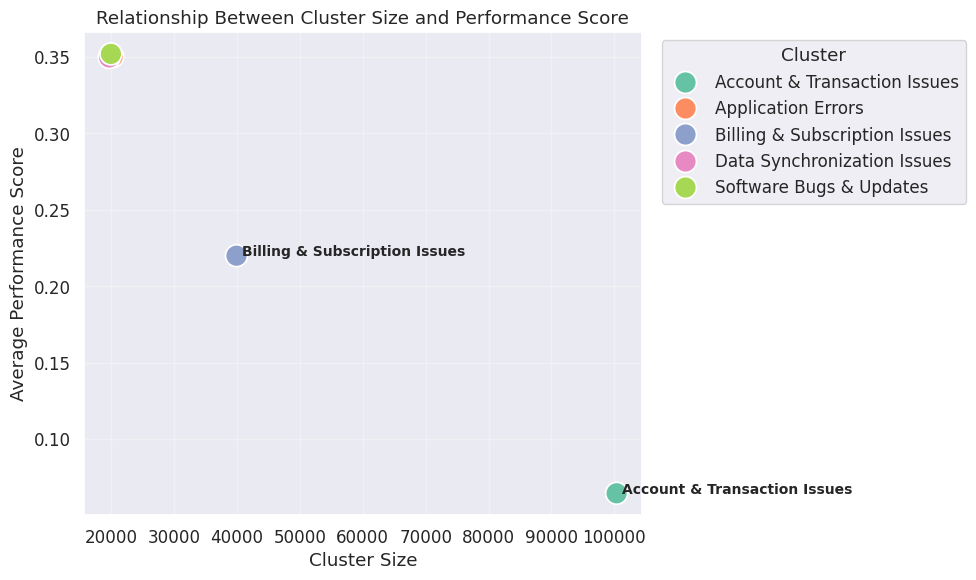

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy
plot_df = cluster_perf.copy()

# Create jitter columns
plot_df['Cluster_Size_Jitter'] = plot_df['Cluster_Size']
plot_df['Performance_Jitter'] = plot_df['Avg_Performance']

# Add small jitter (only for visualization)
plot_df.loc[plot_df['Cluster_Name']=='Application Errors', 'Cluster_Size_Jitter'] += 300
plot_df.loc[plot_df['Cluster_Name']=='Data Synchronization Issues', 'Cluster_Size_Jitter'] -= 300
plot_df.loc[plot_df['Cluster_Name']=='Software Bugs & Updates', 'Performance_Jitter'] += 0.003

# Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_df,
    x='Cluster_Size_Jitter',
    y='Performance_Jitter',
    hue='Cluster_Name',
    s=250,
    palette='Set2'
)

# Label only the important clusters
for _, row in plot_df.iterrows():
    if row['Cluster_Name'] in [
        'Account & Transaction Issues',
        'Billing & Subscription Issues'
    ]:
        plt.text(
            row['Cluster_Size_Jitter'] + 800,
            row['Performance_Jitter'],
            row['Cluster_Name'],
            fontsize=10,
            fontweight='bold'
        )

plt.title("Relationship Between Cluster Size and Performance Score")
plt.xlabel("Cluster Size")
plt.ylabel("Average Performance Score")
plt.grid(alpha=0.3)

plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()